Topics Covered:
- Silhoutte Score
- Dunn Index
- Density Based Clustering algorithm
- DB Scan (Density-Based Spatial Clustering of Applications with Noise).
  - Eps - Eps-neighborhood of an object o is the space within a radius centered at o.
  - minPts - Density theshold of a region
  - Core Point
  - Density Reachable: core object a and an object b
    - b is directly density reachable from a
  - Density connected:
    -   

- Spectral Clustering
- Outlier Detection
  


**Books** : 
-- Data Mining & Technology Concepts - by Jiawei Han, Michellne Kamber
For Clustering

**Silhouette Score**, which is one of the most popular metrics for evaluating clustering quality.  

---

## 🔑 Definition
The **Silhouette Score** measures how similar an object is to its own cluster compared to other clusters. It combines **cohesion** (how close points in the same cluster are) and **separation** (how far points are from points in other clusters).

For a single point \(i\):
- \(a(i)\) = average distance between \(i\) and all other points in the same cluster (intra-cluster distance).
- \(b(i)\) = minimum average distance between \(i\) and all points in any other cluster (nearest-cluster distance).

The silhouette score for point \(i\) is:

\[
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
\]

---

## 📊 Properties
- **Range**: \(-1 \leq s(i) \leq 1\)
  - \(s(i) \approx 1\): Point is well clustered (close to its own cluster, far from others).
  - \(s(i) \approx 0\): Point lies on the boundary between clusters.
  - \(s(i) \approx -1\): Point may be misclassified (closer to another cluster than its own).
- **Overall Silhouette Score**: Average of all \(s(i)\) values across the dataset.

---

## 🧩 Why It Matters
- **Cluster Validation**: Helps determine if clusters are well separated and compact.
- **Model Selection**: Often used to choose the optimal number of clusters (e.g., in K-means).
- **Interpretability**: Provides a simple, intuitive measure of clustering quality.

---

## ✅ Example in Python
Here’s how you can compute it using **scikit-learn**:

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

# Generate sample data
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=42)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42).fit(X)

# Compute silhouette score
score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)
```

If the score is close to **1**, clustering is good; if it’s near **0** or negative, clusters may overlap or be poorly defined.

---

✨ In practice, people often plot the **silhouette values per cluster** to visually inspect which clusters are strong and which are weak.  

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**.

---

## 🔑 Key Concepts in DBSCAN
- **Core Point**: A point with at least `MinPts` neighbors within a radius `ε` (epsilon).
- **Border Point**: A point that is not a core point but lies within the neighborhood of a core point.
- **Noise Point**: A point that is neither a core point nor within the neighborhood of a core point.

---

## 📘 Density-Reachable
In DBSCAN, **density-reachability** is a way to define how points are connected through dense regions.

- A point **p** is **directly density-reachable** from a point **q** if:
  - `q` is a **core point**, and
  - `p` lies within the `ε`-neighborhood of `q`.

- A point **p** is **density-reachable** from a point **q** if:
  - There exists a chain of points \(p_1, p_2, ..., p_n\) such that:
    - \(p_1 = q\) and \(p_n = p\),
    - Each \(p_{i+1}\) is directly density-reachable from \(p_i\).

👉 Importantly:
- Density-reachability is **not symmetric**.  
  - Example: If \(p\) is density-reachable from \(q\), it doesn’t mean \(q\) is density-reachable from \(p\).  
  - This asymmetry happens because only **core points** can directly reach others, while border points cannot.

---

## 🧩 Why It Matters
- DBSCAN uses density-reachability to form clusters:
  - All points that are density-reachable from a given core point belong to the same cluster.
  - Border points can be included in clusters if they are density-reachable from a core point.
  - Noise points are excluded since they are not density-reachable from any core point.

---

### ⚡ Example
Imagine points scattered on a plane:
- If point A is a core point, and point B lies within its `ε`-neighborhood, then B is directly density-reachable from A.
- If B is also a core point, and point C lies within B’s `ε`-neighborhood, then C is density-reachable from A (through B).
- But if C is a border point, it cannot extend reachability further.

---

Cluster labels: [ 0  0  0  1  1 -1]


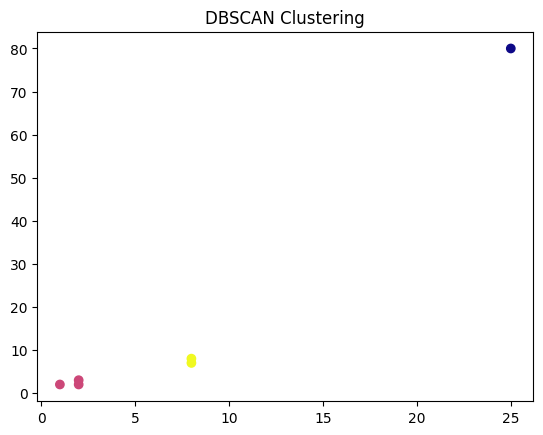

In [2]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Example dataset
# X is a 6x2 matrix
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [25, 80]
])

# Apply DBSCAN
db = DBSCAN(eps=3, min_samples=2).fit(X)

# Cluster labels (-1 means noise)
labels = db.labels_
print("Cluster labels:", labels)

# Plotting
plt.scatter(X[:,0], X[:,1], c=labels, cmap='plasma')
plt.title("DBSCAN Clustering")
plt.show()


In [1]:
import numpy as np

def dbscan(X, eps, min_pts):
    labels = [0] * len(X)  # 0 = unvisited
    cluster_id = 0

    def region_query(point_idx):
        neighbors = []
        for i, p in enumerate(X):
            if np.linalg.norm(X[point_idx] - p) <= eps:
                neighbors.append(i)
        return neighbors

    def expand_cluster(point_idx, neighbors, cluster_id):
        labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            n_idx = neighbors[i]
            if labels[n_idx] == 0:  # unvisited
                labels[n_idx] = cluster_id
                n_neighbors = region_query(n_idx)
                if len(n_neighbors) >= min_pts:
                    neighbors += n_neighbors
            elif labels[n_idx] == -1:  # noise
                labels[n_idx] = cluster_id
            i += 1

    for i in range(len(X)):
        if labels[i] != 0:
            continue
        neighbors = region_query(i)
        if len(neighbors) < min_pts:
            labels[i] = -1  # mark as noise
        else:
            cluster_id += 1
            expand_cluster(i, neighbors, cluster_id)

    return labels

# Example usage
X = np.array([[1,2],[2,2],[2,3],[8,7],[8,8],[25,80]])
labels = dbscan(X, eps=3, min_pts=2)
print("Cluster labels:", labels)


Cluster labels: [1, 1, 1, 2, 2, -1]


**The Rand Index is a statistical measure used to evaluate the similarity between two clustering results, ranging from 0 (no agreement) to 1 (perfect agreement). It compares how pairs of points are grouped together or separated across two different partitions.**

---

## 🔑 Definition
Given a dataset of \(n\) elements and two different clusterings (say, clustering \(X\) and clustering \(Y\)):

- **a** = number of pairs of points that are in the same cluster in both \(X\) and \(Y\).  
- **b** = number of pairs of points that are in different clusters in both \(X\) and \(Y\).  
- **nC2** = total number of possible pairs of points in the dataset.  

The **Rand Index (RI)** is calculated as:

\[
RI = \frac{a + b}{\binom{n}{2}}
\]

---

## 📊 Properties
- **Range**: \(0 \leq RI \leq 1\)  
  - **0** → No similarity between the two clusterings.  
  - **1** → Perfect similarity (the clusterings are identical).  
- **Symmetric**: RI(X, Y) = RI(Y, X).  
- **Adjusted Rand Index (ARI)**: A corrected version that accounts for chance agreements. ARI can take negative values if the agreement is worse than random clustering.  

---

## 🧩 Example
Suppose we have 4 points: \(\{A, B, C, D\}\).

- Clustering 1: \(\{A, B\}, \{C, D\}\)  
- Clustering 2: \(\{A, B, C\}, \{D\}\)

Pairs:
- (A, B): same in both → contributes to **a**.  
- (C, D): same in Clustering 1, different in Clustering 2 → disagreement.  
- (A, C): different in Clustering 1, same in Clustering 2 → disagreement.  
- (B, C): different in Clustering 1, same in Clustering 2 → disagreement.  
- (A, D), (B, D): different in both → contributes to **b**.  

So:
- \(a = 1\) (pair A,B)  
- \(b = 2\) (pairs A,D and B,D)  
- Total pairs = 6  

\[
RI = \frac{1+2}{6} = 0.5
\]

---

## 📌 Why It Matters
- **Clustering Evaluation**: RI is widely used to compare clustering results against a ground truth or between different algorithms.  
- **Interpretability**: Easy to understand since it’s based on pairwise agreements.  
- **Limitations**: RI does not adjust for chance, which is why ARI is often preferred in practice.  

---